In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf

In [5]:
tickers = ["^NSEI", "HDFCBANK.NS", "TCS.NS", "RELIANCE.NS"]

In [6]:
raw_data = yf.download(tickers, start="2025-01-01", end="2026-01-01", auto_adjust=True)

[*********************100%***********************]  4 of 4 completed


In [9]:
prices = raw_data["Close"]
prices.columns = ["NIFTY", "HDFCBANK", "TCS", "RELIANCE"]

In [12]:
# Calcultaion metrics(log returns)
# log_returns: Price_today / Price_yesterday
log_returns = np.log(prices / prices.shift(1)).dropna()

In [14]:
# Volatility
vol = log_returns.std()

In [15]:
print("-----Volatility-----")
print(vol)

-----Volatility-----
NIFTY       0.009817
HDFCBANK    0.012263
TCS         0.012479
RELIANCE    0.007440
dtype: float64


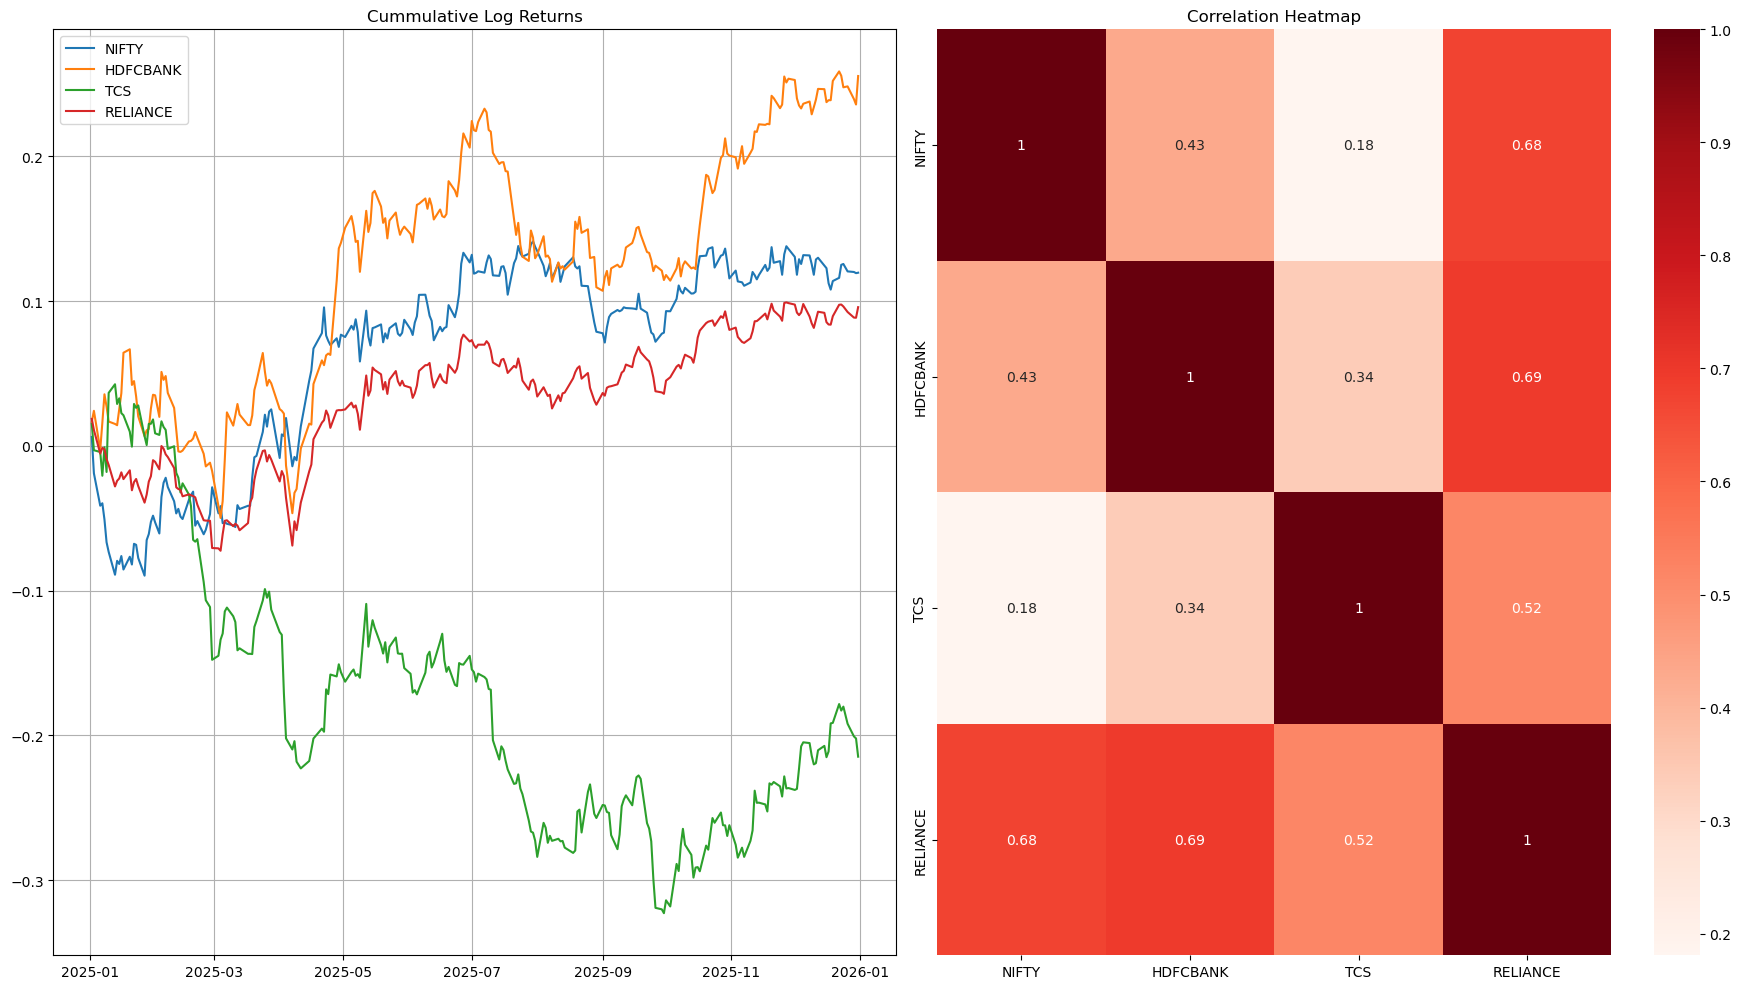

In [35]:
#Charts
plt.subplots(1, 2, figsize=(18, 10))
# 1.Cummlative Log returns
plt.subplot(1, 2, 1)
cum_returns = log_returns.cumsum()
plt.plot(cum_returns)
plt.title("Cummulative Log Returns")
plt.legend(cum_returns.columns)
plt.grid(True)

# 2.Correlation Heatmap
plt.subplot(1, 2, 2)
correlation = log_returns.corr()
sns.heatmap(correlation, annot=True, cmap='Reds')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


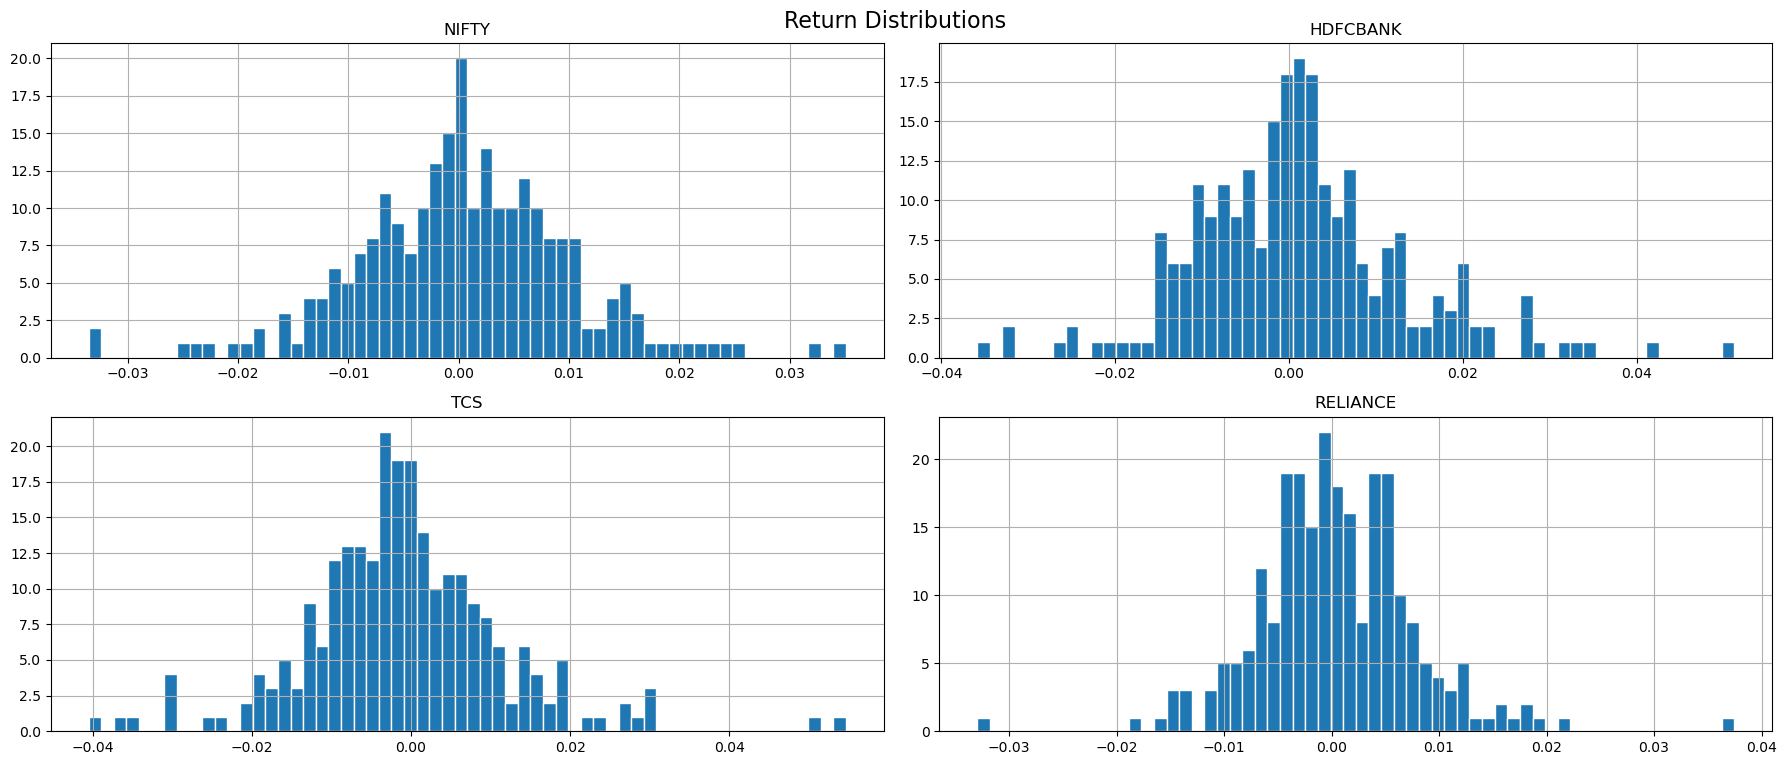

In [32]:
# 3.Return distributions (histogram)
log_returns.hist(bins=60, figsize=(18, 8), layout=(2, 2), edgecolor='white')
plt.suptitle("Return Distributions", y=.95, fontsize=16)
plt.tight_layout()
plt.show()